In [31]:
!pip install numpy matplotlib

  Using cached matplotlib-3.10.8-cp313-cp313-manylinux_2_27_aarch64.manylinux_2_28_aarch64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-manylinux_2_26_aarch64.manylinux_2_28_aarch64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp313-cp313-manylinux2014_aarch64.manylinux_2_17_aarch64.manylinux_2_28_aarch64.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-manylinux_2_24_aarch64.manylinux_2_28_aarch64.whl.metadata (6.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 39.9 MB/s eta 0:00:00MB/s eta 0:00:01
Using cached matplotlib-3.10.8-cp313-cp313-manylinux_2_27_aarch64.manylinux_2_28_aarch64.whl (9.5 MB)
Using cached contourpy-1.3.3-cp313-cp313-manylinux_2_26_aarch64.manylinux_2_28_aarch64.whl (334 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.1-cp313-cp313-manylinux2014_aarch64.manylinux_2_17_aarch64.manylinux_2_28_aarch64.whl (5.

In [130]:
import collections
import glob
import csv
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import TwoSlopeNorm

In [146]:
def load_group(group):
    points = collections.defaultdict(lambda: {})

    for filename in glob.glob("target/criterion/*/*/*/new/raw.csv"):
        with open(filename) as f:
            for record in csv.DictReader(f):
                if record["group"] == group:
                    function = record["function"]
                    size_x, prefix_x = record["value"].split("-")
                    _, size = size_x.split("_")
                    _, prefix = prefix_x.split("_")
                    
                    size = int(size)
                    prefix = int(prefix)
                    measured = float(record["sample_measured_value"])
                    assert record["unit"] == "ns"

                    points[(size, prefix)][function] = measured

    return points

In [199]:
def speedup(group):
    for (size, prefix), m in load_group(group).items():
        if prefix / size <= 1.0:
            yield (size, prefix, m["vendored_std"] / m["partial_sort_1_0_0"])

In [200]:
def plot(group):
    data = list(speedup(group))
    sizes = np.array([d[0] for d in data])
    prefixes = np.array([d[1] for d in data])
    speedups = np.array([d[2] for d in data])
    
    sizes_vals = np.unique(sizes)
    prefixes_vals = np.unique(prefixes)

    Z = np.full((len(prefixes_vals), len(sizes_vals)), np.nan)

    for n, kf, s in data:
        i = np.where(prefixes_vals == kf)[0][0]
        j = np.where(sizes_vals == n)[0][0]
        Z[i, j] = s

    plt.figure()
    plt.pcolormesh(
        sizes_vals,
        prefixes_vals,
        Z,
        shading="nearest",
        cmap="RdYlGn",
        norm=TwoSlopeNorm(vmin=0, vcenter=1.0, vmax=2.0)
    )
    
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("input size N")
    plt.ylabel("prefix fraction K / N")
    plt.colorbar(label="speedup")
    plt.title(f"Speedup {group}")
    plt.show()

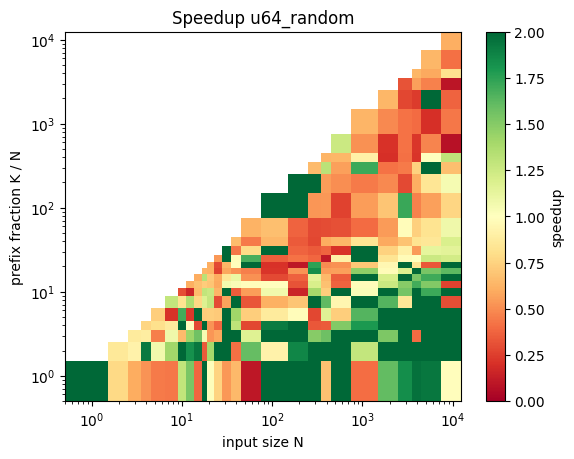

In [201]:
plot("u64_random")

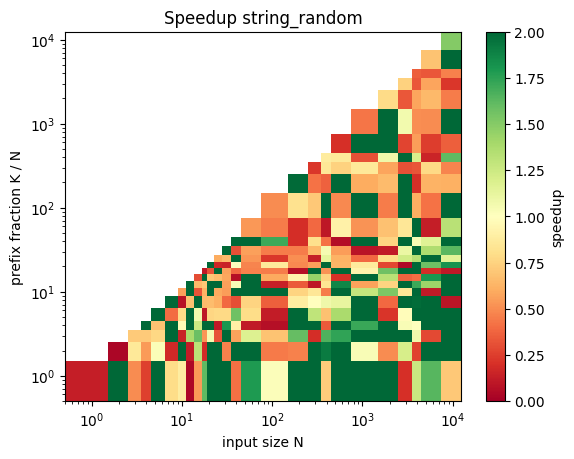

In [202]:
plot("string_random")

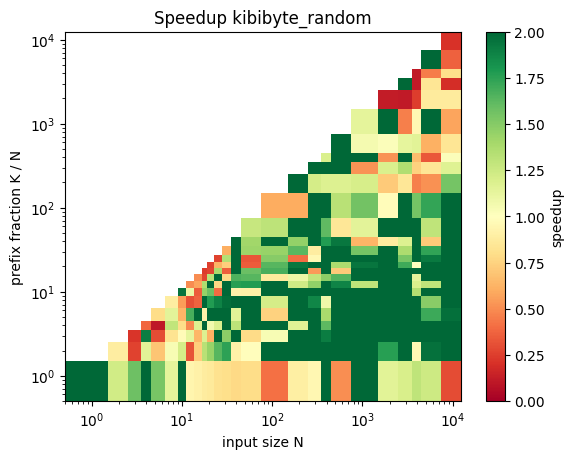

In [203]:
plot("kibibyte_random")